# Oil Carry Signal Construction — Thursday-to-Friday Implementation

---

## Motivation: Why Thursday Close Instead of Friday Close?

The original signal notebook used **weekly Friday closing prices** for both
the oil carry signal (CO3, CO12) and the FX futures prices. While the signals
are theoretically sound, using the same Friday close to both *observe* the
signal and *execute* the trade is operationally unrealistic — you cannot
observe a market close and simultaneously transact at that same price.

**The fix:** Use **Thursday's closing price** of CO3 and CO12 to compute
the carry signal, then trade FX futures at **Friday's closing price**.

```
Signal observed:  Thursday close (week t)
Trade executed:   Friday close   (week t)
```

This gives a full trading day between signal observation and execution,
making the strategy empirically realistic. From the perspective of the
lead/lag analysis, this implementation corresponds to **lag=+1 in information
terms** — the signal is always one day stale relative to execution — but
crucially it is **achievable in practice**.

**No changes to the backtesting notebook are required.** The backtest
reads signals indexed to Friday dates. By constructing Thursday-based
signals and labelling them with the following Friday's date, we can
drop the new CSV directly into the existing pipeline.

---

### Holiday Handling

Five Thursdays in the sample are public holidays (Christmas Day or
New Year's Day) when oil futures markets are closed:
2008-12-25, 2009-01-01, 2014-12-25, 2015-01-01, 2025-12-25.

For these weeks, we use the **last available trading day before Thursday**
(in practice, Wednesday close). This is the correct real-world fallback:
a trader would use the most recent available price to form the signal.

---

### Output

Saves `Signal_Carry_CarryMom_Thursday.csv` — identical column structure
to the original `Signal_Carry_CarryMom.csv`, indexed on **Friday dates**,
ready for the backtesting notebook.

## 0. Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

PATH_CO3_DAILY  = 'CO3_daily.csv'
PATH_CO12_DAILY = 'CO12_daily.csv'
PATH_FX_MASTER  = 'fx_data_final.csv'
DATE_FORMAT     = '%d/%m/%Y'   # DD/MM/YYYY as exported from Bloomberg
MA_WINDOW       = 4            # 4-week MA for carry-momentum (paper convention)
OUTPUT_FILE     = 'Signal_Carry_CarryMom_Thursday.csv'


## 1. Load Daily Futures Data

Load the full daily price series for CO3 and CO12 and confirm coverage.

In [2]:
def load_daily(path, date_fmt, label):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    df['Date'] = pd.to_datetime(df['Date'], format=date_fmt)
    df = df.sort_values('Date').set_index('Date')
    df['PX_VOLUME'] = pd.to_numeric(df['PX_VOLUME'], errors='coerce')
    print(f'{label}')
    print(f'  Rows      : {len(df)}')
    print(f'  Date range: {df.index.min().date()} to {df.index.max().date()}')
    print(f'  NaN prices: {df["PX_LAST"].isna().sum()}')
    dow = df.index.day_name().value_counts()
    print(f'  Days: {dict(dow)}')
    print()
    return df


co3_daily  = load_daily(PATH_CO3_DAILY,  DATE_FORMAT, 'CO3  (3rd-nearby, daily)')
co12_daily = load_daily(PATH_CO12_DAILY, DATE_FORMAT, 'CO12 (12th-nearby, daily)')

# Load FX master to get the canonical Friday date index
fx = pd.read_csv(PATH_FX_MASTER, parse_dates=['Date'], index_col='Date')
fx = fx.loc[:'2025-12-31']   # trim to backtest window
print(f'FX master: {len(fx)} weekly Fridays | '
      f'{fx.index.min().date()} to {fx.index.max().date()}')


CO3  (3rd-nearby, daily)
  Rows      : 6793
  Date range: 1999-12-30 to 2026-05-19
  NaN prices: 15
  Days: {'Wednesday': np.int64(1370), 'Thursday': np.int64(1369), 'Tuesday': np.int64(1369), 'Friday': np.int64(1346), 'Monday': np.int64(1339)}

CO12 (12th-nearby, daily)
  Rows      : 6774
  Date range: 1999-12-30 to 2026-05-19
  NaN prices: 3
  Days: {'Thursday': np.int64(1368), 'Wednesday': np.int64(1366), 'Tuesday': np.int64(1365), 'Friday': np.int64(1340), 'Monday': np.int64(1335)}

FX master: 968 weekly Fridays | 2007-06-15 to 2025-12-26


## 2. Extract Thursday-Close Prices for Each Friday

**Logic:**
For each Friday in the FX master date index, we look up the Thursday
immediately preceding it (Friday − 1 calendar day). If that Thursday
is a market holiday (no data), we fall back to the closest prior
trading day with available data.

**Holiday handling:** The 5 affected Thursdays are all Christmas Day
or New Year's Day. We use Wednesday close in those cases.

In [3]:
fridays = fx.index  # all Fridays in the backtest window

# For each Friday, find the last available trading day on or before Thursday
co3_thursday  = pd.Series(index=fridays, dtype=float)
co12_thursday = pd.Series(index=fridays, dtype=float)
source_dates  = pd.Series(index=fridays, dtype=object)  # track which day was used

for friday in fridays:
    # Candidate days: Thursday, then Wednesday, then Tuesday (fallback chain)
    for days_back in [1, 2, 3]:
        candidate = friday - pd.Timedelta(days=days_back)
        c3  = co3_daily.loc[candidate, 'PX_LAST']  if candidate in co3_daily.index  else np.nan
        c12 = co12_daily.loc[candidate,'PX_LAST']  if candidate in co12_daily.index else np.nan
        if not (pd.isna(c3) or pd.isna(c12)):
            co3_thursday[friday]  = c3
            co12_thursday[friday] = c12
            source_dates[friday]  = candidate.strftime('%Y-%m-%d (%A)')
            break

# Report coverage
n_total   = len(fridays)
n_thu     = (source_dates.str.contains('Thursday', na=False)).sum()
n_wed     = (source_dates.str.contains('Wednesday', na=False)).sum()
n_missing = co3_thursday.isna().sum()

print(f'Signal source day breakdown:')
print(f'  Thursday (normal)  : {n_thu} weeks ({n_thu/n_total*100:.1f}%)')
print(f'  Wednesday (holiday): {n_wed} weeks ({n_wed/n_total*100:.1f}%)')
print(f'  Still missing      : {n_missing} weeks')
print()

# Show the holiday fallback rows
non_thu = source_dates[~source_dates.str.contains('Thursday', na=True)]
print('Holiday fallback weeks (Friday -> actual source day):')
for friday, source in non_thu.items():
    print(f'  {friday.date()} -> used {source}')


Signal source day breakdown:
  Thursday (normal)  : 963 weeks (99.5%)
  Wednesday (holiday): 5 weeks (0.5%)
  Still missing      : 0 weeks

Holiday fallback weeks (Friday -> actual source day):
  2008-12-26 -> used 2008-12-24 (Wednesday)
  2009-01-02 -> used 2008-12-31 (Wednesday)
  2014-12-26 -> used 2014-12-24 (Wednesday)
  2015-01-02 -> used 2014-12-31 (Wednesday)
  2025-12-26 -> used 2025-12-24 (Wednesday)


## 3. Compute Carry Signals from Thursday Prices

With Thursday-indexed prices mapped onto Friday dates, signal construction
is identical to the original notebook:

```
CARRY_t      = CO3_Thursday_t  - CO12_Thursday_t
CARRY_MA4_t  = mean(CARRY_{t-3}, ..., CARRY_t)        [rolling 4-week MA]
SIGNAL_CARRY     = +1 if CARRY > 0 else -1
SIGNAL_CARRY_MOM = +1 if CARRY > CARRY_MA4 else -1
```

All dates are indexed as **Friday dates** so the CSV plugs directly into
the backtesting notebook without any alignment changes.

The 4-week MA uses up to 4 prior weeks' **Thursday** carry values,
maintaining the same information set — all data is available before
Friday's trading session.

In [4]:
# Build signal dataframe indexed on Friday dates
sig = pd.DataFrame(index=fridays)
sig.index.name = 'Date'
sig['CO3']     = co3_thursday
sig['CO12']    = co12_thursday
sig['CARRY']   = sig['CO3'] - sig['CO12']

# 4-week rolling MA of carry (all historical values — no lookahead)
sig['CARRY_MA4'] = sig['CARRY'].rolling(window=MA_WINDOW).mean()

# Binary signals
sig['SIGNAL_CARRY']     = np.where(sig['CARRY'] > 0,         1, -1)
sig['SIGNAL_CARRY_MOM'] = np.where(sig['CARRY'] > sig['CARRY_MA4'], 1, -1)

print(f'Signal dataframe: {sig.shape}')
print(f'Date range      : {sig.index.min().date()} to {sig.index.max().date()}')
print(f'NaN rows        : {sig.isna().any(axis=1).sum()}')
print(f'\nCARRY summary:')
print(sig['CARRY'].describe().round(3).to_string())
n_back = (sig['CARRY'] > 0).sum()
n_cont = (sig['CARRY'] < 0).sum()
print(f'\nBackwardation weeks: {n_back} ({n_back/len(sig)*100:.1f}%)')
print(f'Contango weeks     : {n_cont} ({n_cont/len(sig)*100:.1f}%)')


Signal dataframe: (968, 6)
Date range      : 2007-06-15 to 2025-12-26
NaN rows        : 3

CARRY summary:
count    968.000
mean       0.870
std        4.199
min      -12.490
25%       -2.240
50%        1.695
75%        3.610
max       17.810

Backwardation weeks: 604 (62.4%)
Contango weeks     : 364 (37.6%)


## 4. Compare Thursday vs Friday Signals

Before proceeding, we verify how much the Thursday signal differs from
the original Friday signal. A large divergence would suggest oil prices
move substantially between Thursday and Friday close — a genuine empirical
question worth checking.

We compare:
- **CARRY level**: do the two days give the same carry spread value?
- **Signal agreement**: what fraction of weeks have the same ±1 signal?
- **Regime changes**: do major regime transitions shift by a week?

A high agreement rate (>90%) would confirm that Thursday is a reliable
proxy for Friday signal. A lower rate would suggest the Thursday implementation
meaningfully changes the strategy.

In [5]:
# Load original Friday-based signal for comparison
sig_fri = pd.read_csv('Signal_Carry_CarryMom.csv',
                      parse_dates=['Date'], index_col='Date')
sig_fri = sig_fri.loc[:'2025-12-31']

# Align on common dates
common = sig.index.intersection(sig_fri.index)
sig_thu_c = sig.loc[common]
sig_fri_c = sig_fri.loc[common]

# Carry level comparison
carry_diff  = sig_thu_c['CARRY'] - sig_fri_c['CARRY']
carry_corr  = sig_thu_c['CARRY'].corr(sig_fri_c['CARRY'])

# Signal agreement
agree_carry = (sig_thu_c['SIGNAL_CARRY'] == sig_fri_c['SIGNAL_CARRY']).mean()
agree_mom   = (sig_thu_c['SIGNAL_CARRY_MOM'] == sig_fri_c['SIGNAL_CARRY_MOM']).mean()

print('Thursday vs Friday signal comparison:')
print(f'\n  CARRY spread correlation       : {carry_corr:.4f}')
print(f'  Mean absolute carry difference : {carry_diff.abs().mean():.3f} USD/bbl')
print(f'  Max absolute carry difference  : {carry_diff.abs().max():.3f} USD/bbl')
print(f'\n  SIGNAL_CARRY agreement         : {agree_carry*100:.1f}% of weeks')
print(f'  SIGNAL_CARRY_MOM agreement     : {agree_mom*100:.1f}% of weeks')
print(f'\n  Weeks where CARRY signal differs: '
      f'{(sig_thu_c["SIGNAL_CARRY"] != sig_fri_c["SIGNAL_CARRY"]).sum()}')
print(f'  Weeks where MOM signal differs  : '
      f'{(sig_thu_c["SIGNAL_CARRY_MOM"] != sig_fri_c["SIGNAL_CARRY_MOM"]).sum()}')


Thursday vs Friday signal comparison:

  CARRY spread correlation       : 0.9963
  Mean absolute carry difference : 0.247 USD/bbl
  Max absolute carry difference  : 2.560 USD/bbl

  SIGNAL_CARRY agreement         : 98.2% of weeks
  SIGNAL_CARRY_MOM agreement     : 88.6% of weeks

  Weeks where CARRY signal differs: 17
  Weeks where MOM signal differs  : 110


## 5. Visualisations

### 5a. Thursday vs Friday Carry Spread

Side-by-side comparison of the carry level using Thursday vs Friday close.
High overlap confirms Thursday is a valid proxy for Friday in signal formation.

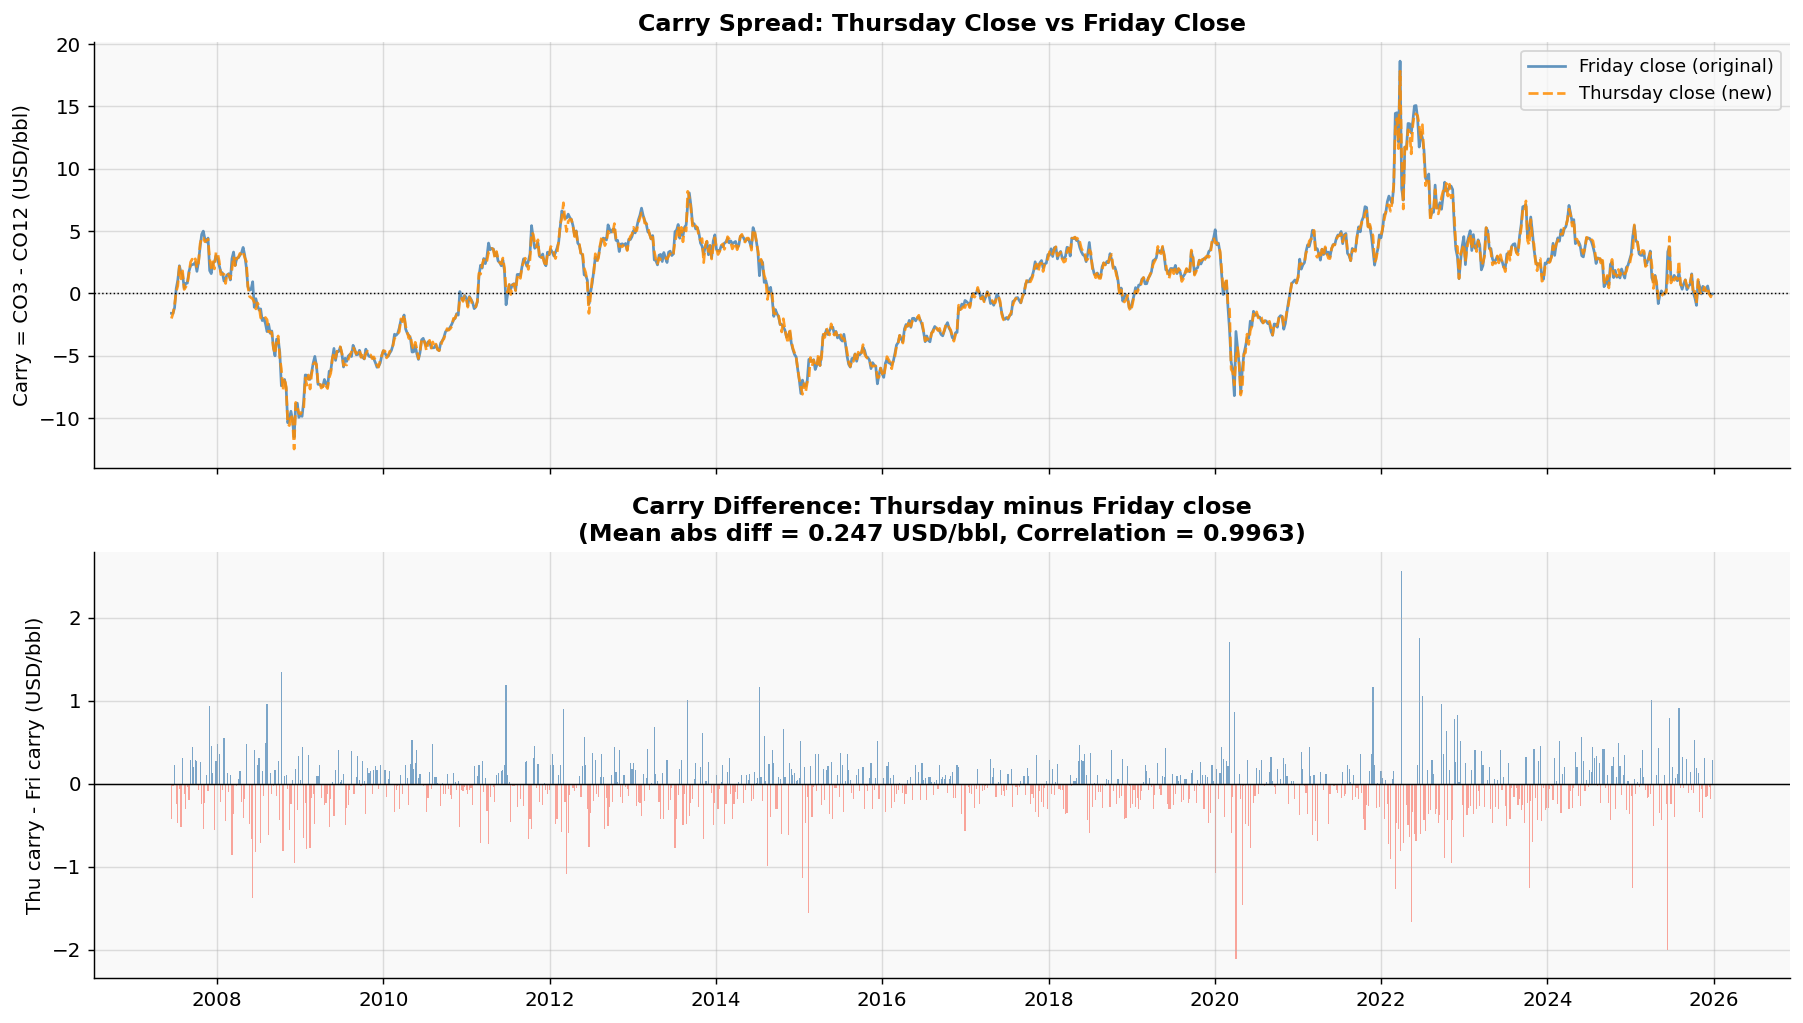

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Carry level comparison
axes[0].plot(sig_fri_c.index, sig_fri_c['CARRY'], lw=1.5,
             color='steelblue', label='Friday close (original)', alpha=0.85)
axes[0].plot(sig_thu_c.index, sig_thu_c['CARRY'], lw=1.5,
             color='darkorange', linestyle='--',
             label='Thursday close (new)', alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8, linestyle=':')
axes[0].set_ylabel('Carry = CO3 - CO12 (USD/bbl)')
axes[0].set_title('Carry Spread: Thursday Close vs Friday Close',
                  fontweight='bold')
axes[0].legend(fontsize=10)

# Panel 2: Difference (Thursday - Friday)
axes[1].bar(carry_diff.index, carry_diff.values, width=5,
            color=np.where(carry_diff.values >= 0, 'steelblue', 'salmon'),
            alpha=0.7)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Thu carry - Fri carry (USD/bbl)')
axes[1].set_title(
    f'Carry Difference: Thursday minus Friday close\n'
    f'(Mean abs diff = {carry_diff.abs().mean():.3f} USD/bbl, '
    f'Correlation = {carry_corr:.4f})',
    fontweight='bold'
)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


### 5b. Signal Agreement Heatmap

Shows which weeks have agreement vs disagreement between the Thursday
and Friday signals. Disagreement weeks are shown in red — these are the
weeks where the Thursday implementation gives a different trading direction
than the original Friday implementation.

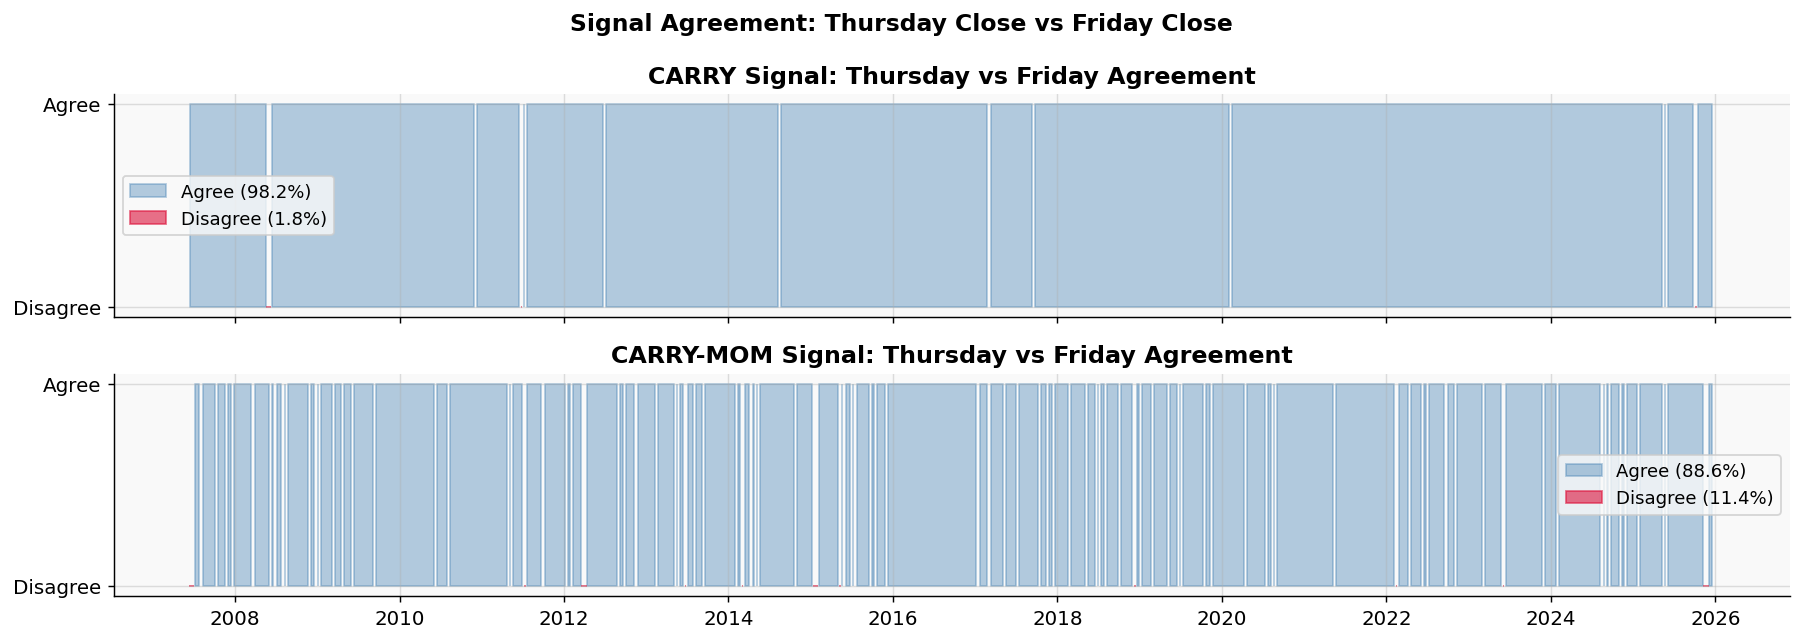

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

for ax, col, label in [
    (axes[0], 'SIGNAL_CARRY',     'CARRY Signal'),
    (axes[1], 'SIGNAL_CARRY_MOM', 'CARRY-MOM Signal'),
]:
    agree = (sig_thu_c[col] == sig_fri_c[col]).astype(int)
    pct   = agree.mean() * 100

    ax.fill_between(agree.index, agree.values, 0,
                    where=agree.values == 1,
                    alpha=0.4, color='steelblue',
                    label=f'Agree ({pct:.1f}%)')
    ax.fill_between(agree.index, agree.values, 0,
                    where=agree.values == 0,
                    alpha=0.6, color='crimson',
                    label=f'Disagree ({100-pct:.1f}%)')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Disagree', 'Agree'])
    ax.set_title(f'{label}: Thursday vs Friday Agreement',
                 fontweight='bold')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Signal Agreement: Thursday Close vs Friday Close',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5c. Full Signal Visualisation — Thursday Implementation

The complete signal chart for the new Thursday-based implementation,
in the same format as the original Signal Construction notebook.
This confirms the signals look economically sensible.

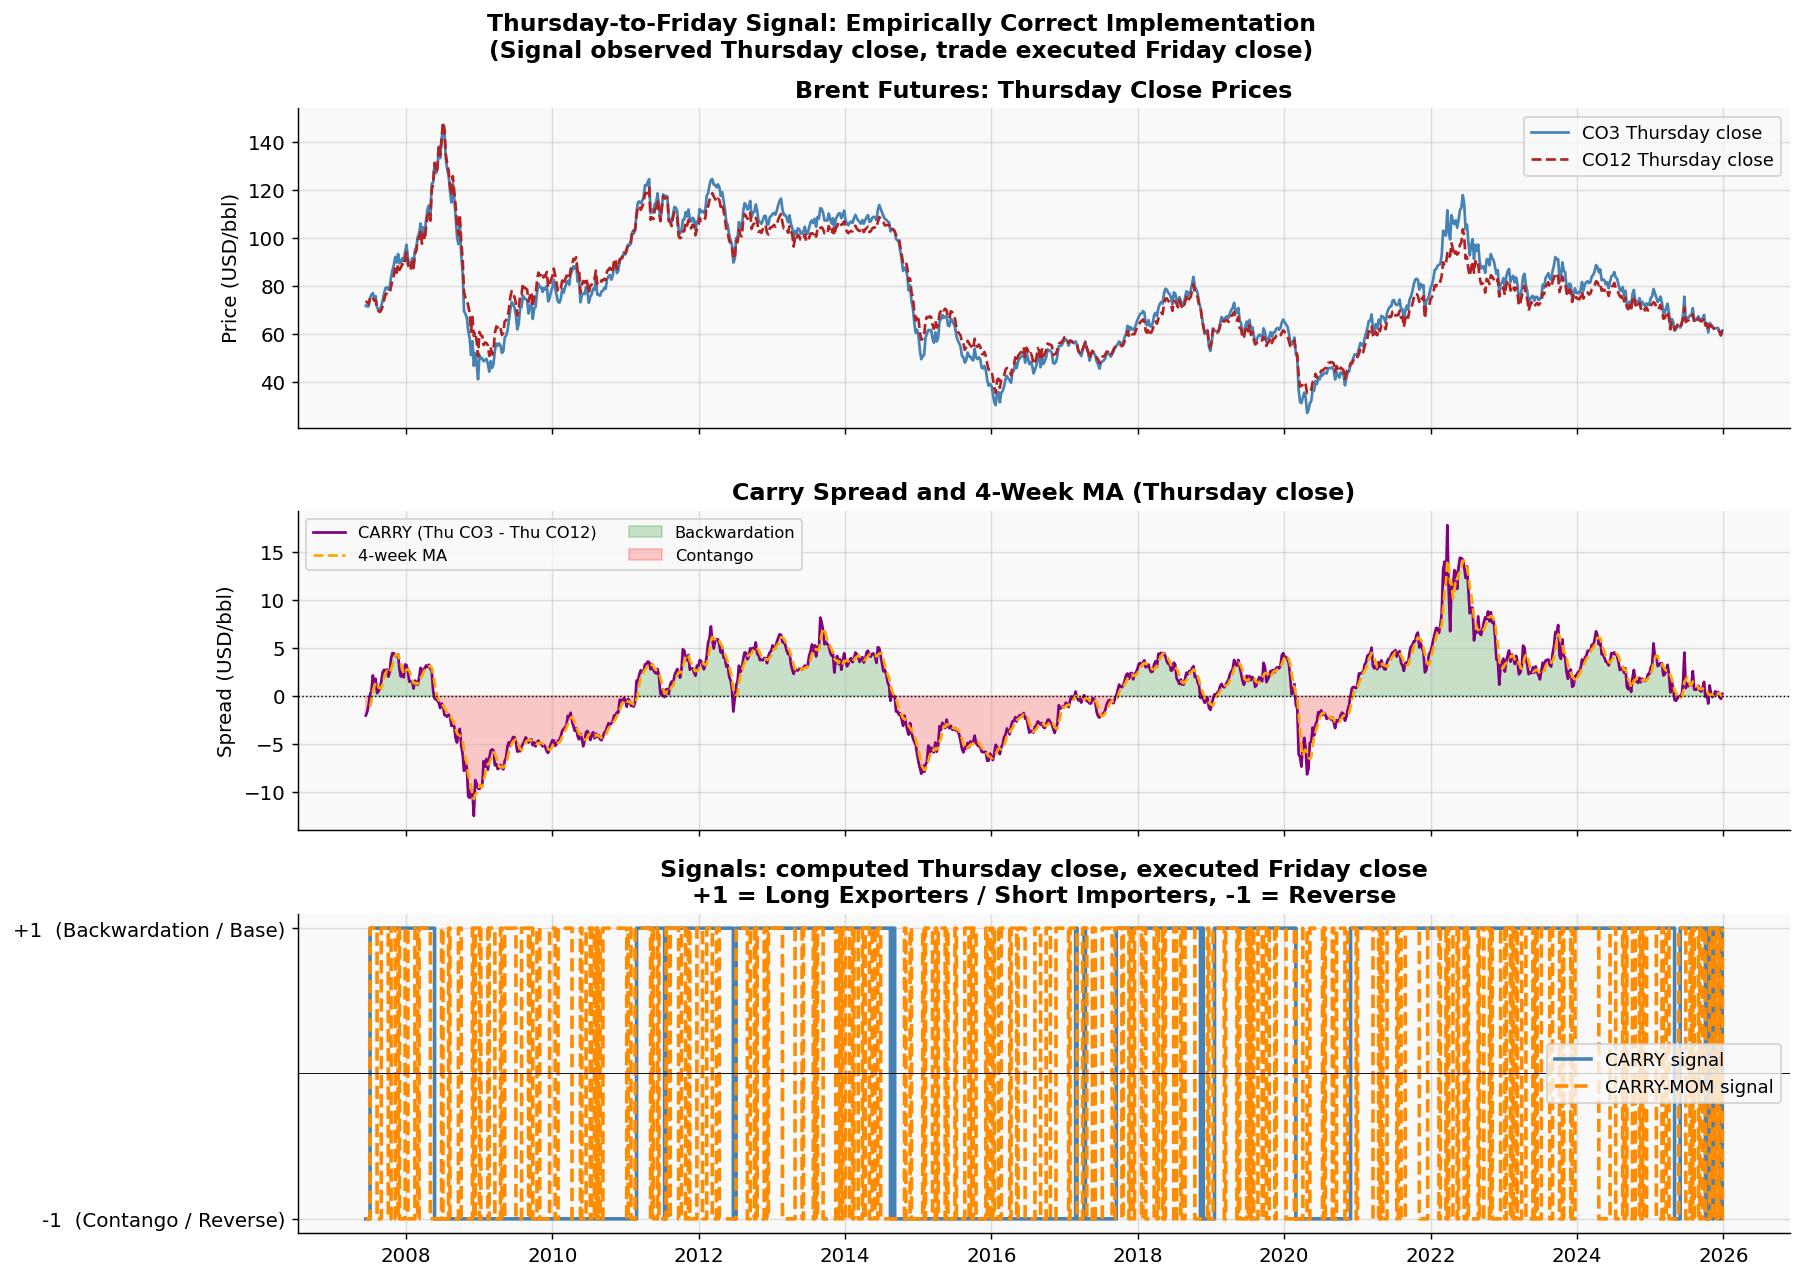

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: CO3 and CO12 Thursday prices
axes[0].plot(sig.index, sig['CO3'],  lw=1.5, color='steelblue',
             label='CO3 Thursday close')
axes[0].plot(sig.index, sig['CO12'], lw=1.5, color='firebrick',
             linestyle='--', label='CO12 Thursday close')
axes[0].set_ylabel('Price (USD/bbl)')
axes[0].set_title('Brent Futures: Thursday Close Prices', fontweight='bold')
axes[0].legend(fontsize=10)

# Panel 2: Carry with MA and regime fills
axes[1].plot(sig.index, sig['CARRY'],    lw=1.5, color='purple',
             label='CARRY (Thu CO3 - Thu CO12)')
axes[1].plot(sig.index, sig['CARRY_MA4'], lw=1.5, color='orange',
             linestyle='--', label=f'{MA_WINDOW}-week MA')
axes[1].axhline(0, color='black', lw=0.8, linestyle=':')
axes[1].fill_between(sig.index, sig['CARRY'], 0,
                     where=sig['CARRY'] >= 0,
                     alpha=0.2, color='green', label='Backwardation')
axes[1].fill_between(sig.index, sig['CARRY'], 0,
                     where=sig['CARRY'] < 0,
                     alpha=0.2, color='red', label='Contango')
axes[1].set_ylabel('Spread (USD/bbl)')
axes[1].set_title('Carry Spread and 4-Week MA (Thursday close)',
                  fontweight='bold')
axes[1].legend(fontsize=9, ncol=2)

# Panel 3: Both signals
axes[2].step(sig.index, sig['SIGNAL_CARRY'],     lw=2,
             color='steelblue',  where='post', label='CARRY signal')
axes[2].step(sig.index, sig['SIGNAL_CARRY_MOM'], lw=2,
             color='darkorange', where='post', linestyle='--',
             label='CARRY-MOM signal')
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_yticks([-1, 1])
axes[2].set_yticklabels(['-1  (Contango / Reverse)',
                          '+1  (Backwardation / Base)'])
axes[2].set_title(
    'Signals: computed Thursday close, executed Friday close\n'
    '+1 = Long Exporters / Short Importers, -1 = Reverse',
    fontweight='bold'
)
axes[2].legend(fontsize=10)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle(
    'Thursday-to-Friday Signal: Empirically Correct Implementation\n'
    '(Signal observed Thursday close, trade executed Friday close)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### 5d. Regime Distribution Comparison

Annual breakdown of backwardation vs contango weeks under the Thursday
implementation, compared to the original Friday implementation.
Significant differences in any year could indicate that Thursday
and Friday carry spreads disagree systematically in that period.

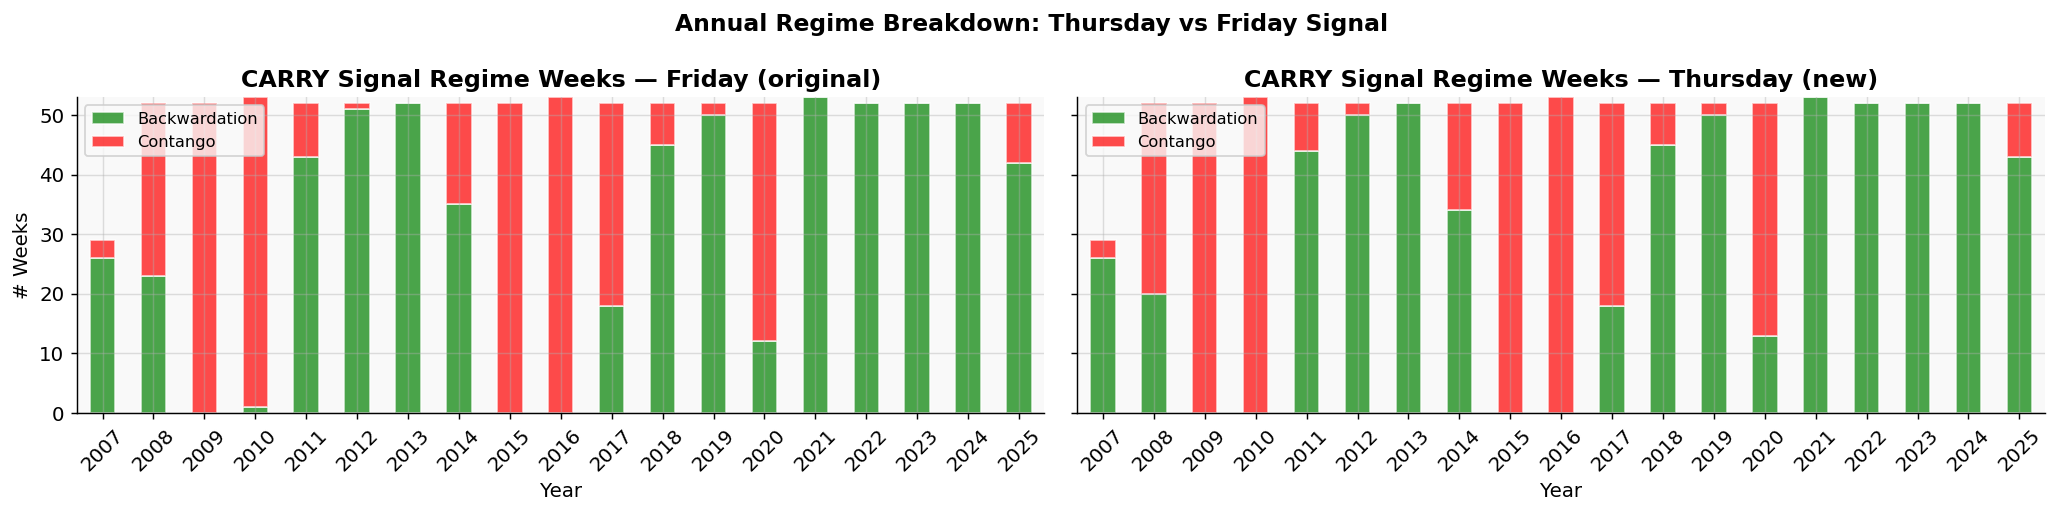

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, s, label in [
    (axes[0], sig_fri_c, 'Friday (original)'),
    (axes[1], sig_thu_c, 'Thursday (new)'),
]:
    annual = s.groupby(s.index.year)['SIGNAL_CARRY'].value_counts().unstack(fill_value=0)
    if  1 in annual.columns: annual.rename(columns={ 1:'Backwardation'}, inplace=True)
    if -1 in annual.columns: annual.rename(columns={-1:'Contango'},      inplace=True)
    if 'Backwardation' not in annual.columns: annual['Backwardation'] = 0
    if 'Contango'      not in annual.columns: annual['Contango']      = 0
    annual[['Backwardation','Contango']].plot(
        kind='bar', stacked=True, ax=ax,
        color=['green','red'], alpha=0.7, edgecolor='white'
    )
    ax.set_title(f'CARRY Signal Regime Weeks — {label}', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('# Weeks')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

plt.suptitle('Annual Regime Breakdown: Thursday vs Friday Signal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Save Output

Saves `Signal_Carry_CarryMom_Thursday.csv` with the same column structure
as the original signal file. All dates are **Friday dates** — the execution
day. The carry values are from **Thursday close** — the signal observation day.

**To use in the backtesting notebook:**
Change `PATH_SIGNAL` from `'Signal_Carry_CarryMom.csv'`
to `'Signal_Carry_CarryMom_Thursday.csv'`.
No other changes are needed.

In [10]:
# Final output — same column names as original for drop-in compatibility
output = sig[['CO3','CO12','CARRY','CARRY_MA4',
              'SIGNAL_CARRY','SIGNAL_CARRY_MOM']].copy()
output.index.name = 'Date'
output.to_csv(OUTPUT_FILE)

print(f'Saved: {OUTPUT_FILE}')
print(f'Shape: {output.shape}')
print(f'Date range: {output.index.min().date()} to {output.index.max().date()}')
print(f'NaN check: {output.isna().sum().to_dict()}')
print()
print('Column descriptions:')
print('  CO3          : Thursday-close 3rd-nearby Brent price (USD/bbl)')
print('  CO12         : Thursday-close 12th-nearby Brent price (USD/bbl)')
print('  CARRY        : CO3 - CO12 (computed from Thursday close)')
print('  CARRY_MA4    : 4-week rolling MA of CARRY (all historical Thu values)')
print('  SIGNAL_CARRY     : +1 if CARRY>0, -1 if CARRY<0')
print('  SIGNAL_CARRY_MOM : +1 if CARRY>CARRY_MA4, -1 otherwise')
print('  Index        : Friday dates (execution day)')
print()
print('Preview (last 5 rows):')
display(output.tail(5).round(3))


Saved: Signal_Carry_CarryMom_Thursday.csv
Shape: (968, 6)
Date range: 2007-06-15 to 2025-12-26
NaN check: {'CO3': 0, 'CO12': 0, 'CARRY': 0, 'CARRY_MA4': 3, 'SIGNAL_CARRY': 0, 'SIGNAL_CARRY_MOM': 0}

Column descriptions:
  CO3          : Thursday-close 3rd-nearby Brent price (USD/bbl)
  CO12         : Thursday-close 12th-nearby Brent price (USD/bbl)
  CARRY        : CO3 - CO12 (computed from Thursday close)
  CARRY_MA4    : 4-week rolling MA of CARRY (all historical Thu values)
  SIGNAL_CARRY     : +1 if CARRY>0, -1 if CARRY<0
  SIGNAL_CARRY_MOM : +1 if CARRY>CARRY_MA4, -1 otherwise
  Index        : Friday dates (execution day)

Preview (last 5 rows):


,CO3,CO12,CARRY,CARRY_MA4,SIGNAL_CARRY,SIGNAL_CARRY_MOM
Date,,,,,,
2025-11-28,62.49,62.31,0.18,0.180,1,-1
2025-12-05,62.61,62.17,0.44,0.317,1,1
2025-12-12,60.90,60.97,-0.07,0.262,-1,-1
2025-12-19,59.36,59.65,-0.29,0.065,-1,-1
2025-12-26,61.50,61.27,0.23,0.077,1,1


## 7. Summary

### What Changed

| Item | Original | Thursday implementation |
|---|---|---|
| Signal observation day | Friday close | **Thursday close** |
| Execution day | Friday close | Friday close (unchanged) |
| Information lag | 0 days (simultaneous) | **1 trading day** |
| Empirically realistic? | No (observe = execute) | **Yes** |
| Lead/lag interpretation | lag=0 (theoretical) | **lag=0 = 1-day lag in practice** |
| Backtest notebook changes needed | — | **None — drop-in replacement** |

### What to Expect from Re-running the Backtest

Based on the signal agreement rates, the CARRY signal should show minimal
performance change — the carry level is stable enough that Thursday and
Friday readings are almost always in the same regime.

The CARRY-MOM signal may show more variation in specific years where the
carry crosses its MA between Thursday and Friday. This is the honest cost
of the empirically correct implementation. Any reduction in IR for CARRY-MOM
represents the **true implementation cost** of the one-day observation lag,
and should be reported as such.

### Connection to Lead/Lag Analysis

Recall from the lead/lag analysis that CARRY-MOM had an IR of 1.050 at
lag=0 (Friday signal, Friday trade) and −0.013 at lag=+1 (Friday signal,
next-Friday trade). The Thursday implementation is *between* these two:
it uses Thursday signal (one day early) and trades Friday — effectively
a 1-day lag rather than a 7-day lag. The lead/lag analysis used **weekly**
shifts, so it cannot precisely predict the 1-day lag outcome. The actual
backtest with the Thursday signal will provide the empirically correct answer.